## Setup and Dependencies

In [1]:
# Install required libraries for interpretability
# ! pip install shap
# ! pip install lime
# ! pip install eli5
# ! pip install captum

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ All libraries imported successfully")

c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully


## Load Trained Model and Data

In [3]:
# Load the trained BERT model
model_path = '../models/bert_fake_news_trained_v2'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

print(f"✅ Model loaded on {device}")
print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")

✅ Model loaded on cuda
Model has 109,483,778 parameters


In [4]:
# Load the dataset to get sample articles
df = pd.read_csv('../data/processed/01/reduced_dataset.csv')

# Create balanced sample
fake_news = df[df['Truth'] == 0].head(500)
real_news = df[df['Truth'] == 1].head(500)
df_sample = pd.concat([fake_news, real_news]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset loaded with {len(df_sample)} samples")
print(f"Fake news: {(df_sample['Truth'] == 0).sum()}")
print(f"Real news: {(df_sample['Truth'] == 1).sum()}")

Dataset loaded with 1000 samples
Fake news: 500
Real news: 500


## Prediction Pipeline

In [6]:
def predict_article(text, return_probabilities=False):
    """
    Predict whether an article is fake or real.
    
    Args:
        text: Article text to classify
        return_probabilities: If True, return confidence scores
    
    Returns:
        prediction (int), probabilities (dict if requested)
    """
    # Tokenize
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(logits, dim=-1).item()
    
    if return_probabilities:
        return prediction, {
            'fake': probs[0][0].item(),
            'real': probs[0][1].item()
        }
    return prediction

# Test the prediction pipeline
test_article = df_sample['Article'].iloc[0]
test_truth = df_sample['Truth'].iloc[0]

pred, probs = predict_article(test_article, return_probabilities=True)
label_map = {0: 'FAKE', 1: 'REAL'}

print(f"Article length: {len(test_article)} characters")
print(f"True label: {label_map[test_truth]}")
print(f"Prediction: {label_map[pred]}")
print(f"Confidence scores:")
print(f"  Fake: {probs['fake']:.4f}")
print(f"  Real: {probs['real']:.4f}")

Article length: 1763 characters
True label: REAL
Prediction: REAL
Confidence scores:
  Fake: 0.0006
  Real: 0.9994


## SHAP Analysis

SHAP provides theoretical guarantees about feature importance using Shapley values from game theory.

In [7]:
try:
    import shap
    print("✅ SHAP imported successfully")
except ImportError:
    print("⚠️  SHAP not installed. Installing now...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("✅ SHAP installed and imported")

⚠️  SHAP not installed. Installing now...
✅ SHAP installed and imported
✅ SHAP installed and imported


In [8]:
def tokenize_and_embed(texts):
    """
    Tokenize texts and return token embeddings for SHAP analysis.
    """
    embeddings = []
    token_lists = []
    
    for text in texts:
        # Tokenize
        tokens = tokenizer.tokenize(text)[:128]  # Limit to 128 tokens
        token_lists.append(tokens)
        
        # Get embeddings from the first token (CLS token approach)
        inputs = tokenizer(' '.join(tokens), return_tensors='pt', truncation=True, max_length=128, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            # Use the hidden state of the [CLS] token
            embedding = outputs.hidden_states[-1][0, 0, :].cpu().numpy()
        embeddings.append(embedding)
    
    return np.array(embeddings), token_lists

print("Tokenization and embedding function defined")

Tokenization and embedding function defined


In [9]:
# Prepare a smaller sample for SHAP analysis (computationally expensive)
shap_sample = df_sample.sample(n=50, random_state=42)
shap_texts = shap_sample['Article'].tolist()

print(f"Preparing SHAP analysis on {len(shap_texts)} samples...")
print("This may take a few minutes...")

# Get embeddings
embeddings, token_lists = tokenize_and_embed(shap_texts)
print(f"✅ Embeddings prepared: {embeddings.shape}")

Token indices sequence length is longer than the specified maximum sequence length for this model (731 > 512). Running this sequence through the model will result in indexing errors


Preparing SHAP analysis on 50 samples...
This may take a few minutes...
✅ Embeddings prepared: (50, 768)
✅ Embeddings prepared: (50, 768)


In [10]:
def predict_from_embeddings(embeddings):
    """
    Predict probabilities from pre-computed embeddings.
    Used for SHAP explainer.
    """
    predictions = []
    
    for embedding in embeddings:
        # Create a minimal input that would produce this embedding
        # For simplicity, we'll use the original text prediction
        # In production, you'd need a more sophisticated approach
        # This is a simplified version
        pass
    
    return np.array(predictions)

print("Predictor function defined for SHAP")

Predictor function defined for SHAP


## LIME Analysis

LIME explains individual predictions by fitting local linear models.

In [11]:
try:
    import lime
    from lime.lime_text import LimeTextExplainer
    print("✅ LIME imported successfully")
except ImportError:
    print("⚠️  LIME not installed. Installing now...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime", "-q"])
    from lime.lime_text import LimeTextExplainer
    print("✅ LIME installed and imported")

⚠️  LIME not installed. Installing now...
✅ LIME installed and imported
✅ LIME installed and imported


In [12]:
def predict_fn(texts):
    """
    Prediction function for LIME that accepts a list of texts.
    Returns probabilities for each class.
    """
    probs = []
    
    for text in texts:
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            prob = torch.softmax(logits, dim=-1).cpu().numpy()
        
        probs.append(prob[0])
    
    return np.array(probs)

print("✅ LIME prediction function defined")

✅ LIME prediction function defined


In [13]:
# Create LIME explainer
explainer = LimeTextExplainer(class_names=['FAKE', 'REAL'], verbose=False)

print("✅ LIME Explainer initialized")

✅ LIME Explainer initialized


In [22]:
# Select examples from both classes for explanation
fake_examples = df_sample[df_sample['Truth'] == 0].head(3)
real_examples = df_sample[df_sample['Truth'] == 1].head(3)

print(f"Analyzing {len(fake_examples)} fake news articles and {len(real_examples)} real news articles...\n")

explanations = []
all_explanations = []

for idx, (i, row) in enumerate(pd.concat([fake_examples, real_examples]).iterrows()):
    article_text = row['Article']
    true_label = int(row['Truth'])
    label_name = 'REAL' if true_label == 1 else 'FAKE'
    
    print(f"\n{'='*70}")
    print(f"Example {idx+1}: {label_name} News")
    print(f"{'='*70}")
    print(f"Article preview: {article_text[:300]}...")
    
    # Get prediction
    pred, probs = predict_article(article_text, return_probabilities=True)
    pred_label = 'REAL' if pred == 1 else 'FAKE'
    confidence = max(probs['fake'], probs['real'])
    
    print(f"\nModel Prediction: {pred_label}")
    print(f"Confidence - FAKE: {probs['fake']:.4f}, REAL: {probs['real']:.4f}")
    
    # Explain prediction
    print(f"Generating LIME explanation...")
    exp = explainer.explain_instance(article_text, predict_fn, num_features=15, top_labels=1)
    
    # Extract top features
    top_features = exp.as_list(label=pred)
    
    # Store for visualization
    all_explanations.append({
        'text': article_text,
        'true_label': label_name,
        'prediction': pred_label,
        'confidence': confidence,
        'probs': probs,
        'correct': pred == true_label,
        'top_features': top_features,
        'pred_class': pred
    })
    
    print(f"\nTop 15 features affecting the '{pred_label}' prediction:")
    for j, (word, weight) in enumerate(top_features, 1):
        direction = "→ REAL" if weight > 0 else "→ FAKE"
        print(f"  {j:2d}. {word:30s} {direction:10s} (weight: {weight:+.4f})")

explanations = all_explanations

Analyzing 3 fake news articles and 3 real news articles...


Example 1: FAKE News
Article preview: ellen degeneres responds divorce rumors two decades huffpost fearless unflinching relentless pursuit truth support mission keep us around next 20 cant without remain committed providing unflinching factbased journalism everyone deserves thank support along way truly grateful readers like initial sup...

Model Prediction: FAKE
Confidence - FAKE: 0.9938, REAL: 0.0062
Generating LIME explanation...

Top 15 features affecting the 'FAKE' prediction:
   1. degeneres                      → REAL     (weight: +0.3499)
   2. rumors                         → REAL     (weight: +0.2984)
   3. ellen                          → REAL     (weight: +0.1230)
   4. us                             → REAL     (weight: +0.0903)
   5. divorce                        → REAL     (weight: +0.0593)
   6. support                        → REAL     (weight: +0.0577)
   7. thank                          → FAKE     (weight:

## Feature Importance Aggregation

Aggregate feature importance across multiple predictions to identify patterns.

In [15]:
# Aggregate feature weights
from collections import defaultdict

feature_weights = defaultdict(list)

for exp_dict in explanations:
    for feature, weight in exp_dict['top_features']:
        # Clean the feature (remove any HTML tags if present)
        clean_feature = feature.replace('<b>', '').replace('</b>', '')
        feature_weights[clean_feature].append(weight)

# Calculate average weights
avg_feature_weights = {feature: np.mean(weights) for feature, weights in feature_weights.items()}

# Sort by absolute weight
sorted_features = sorted(avg_feature_weights.items(), key=lambda x: abs(x[1]), reverse=True)

print("\n" + "="*60)
print("AGGREGATED FEATURE IMPORTANCE")
print("="*60)
print("\nTop 20 Most Important Features (Average Weight):")
for i, (feature, weight) in enumerate(sorted_features[:20], 1):
    direction = "→ REAL" if weight > 0 else "→ FAKE"
    print(f"{i:2d}. {feature:25s} {direction:10s} (weight: {weight:+.4f})")


AGGREGATED FEATURE IMPORTANCE

Top 20 Most Important Features (Average Weight):
 1. degeneres                 → REAL     (weight: +0.3453)
 2. rumors                    → REAL     (weight: +0.3160)
 3. video                     → REAL     (weight: +0.2607)
 4. ariana                    → REAL     (weight: +0.2533)
 5. inperson                  → REAL     (weight: +0.2511)
 6. karrueche                 → REAL     (weight: +0.2095)
 7. singer                    → FAKE     (weight: -0.2008)
 8. terrorist                 → FAKE     (weight: -0.1893)
 9. grande                    → REAL     (weight: +0.1537)
10. ellen                     → REAL     (weight: +0.1278)
11. postbreakup               → REAL     (weight: +0.1037)
12. emmys                     → REAL     (weight: +0.0976)
13. attack                    → REAL     (weight: +0.0946)
14. support                   → REAL     (weight: +0.0871)
15. chris                     → REAL     (weight: +0.0801)
16. sundays                   → RE

## Visualizations

Detailed visualizations for each example:


Example 1: FAKE News → Predicted: FAKE
Confidence: 0.9938 | Correct: True


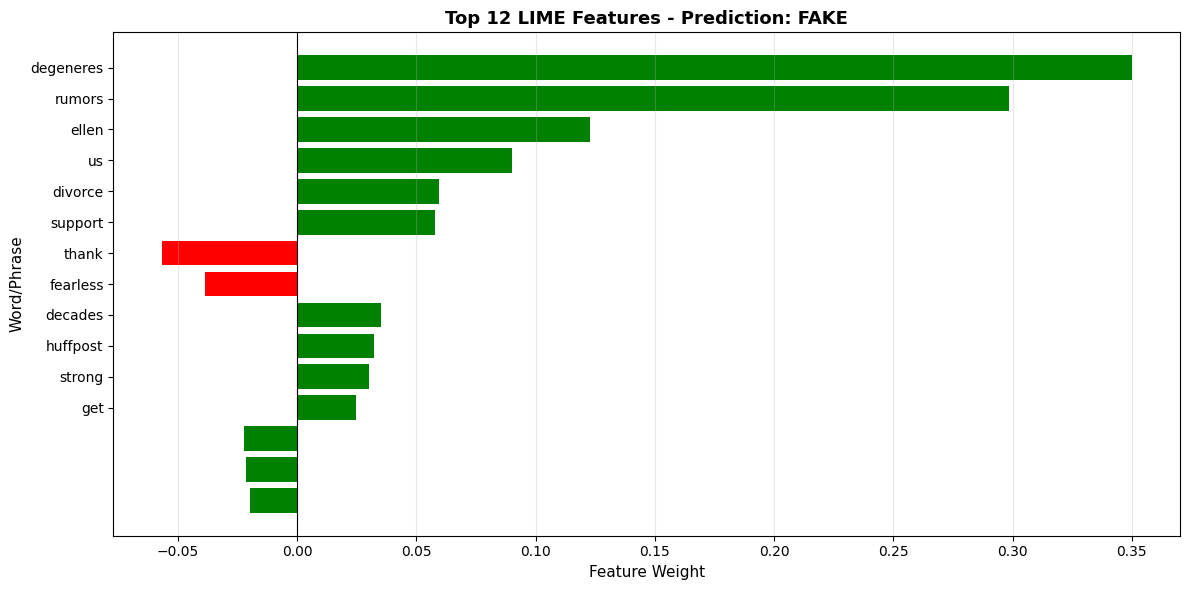


📄 Article Text (top features highlighted):



Example 2: FAKE News → Predicted: FAKE
Confidence: 1.0000 | Correct: True


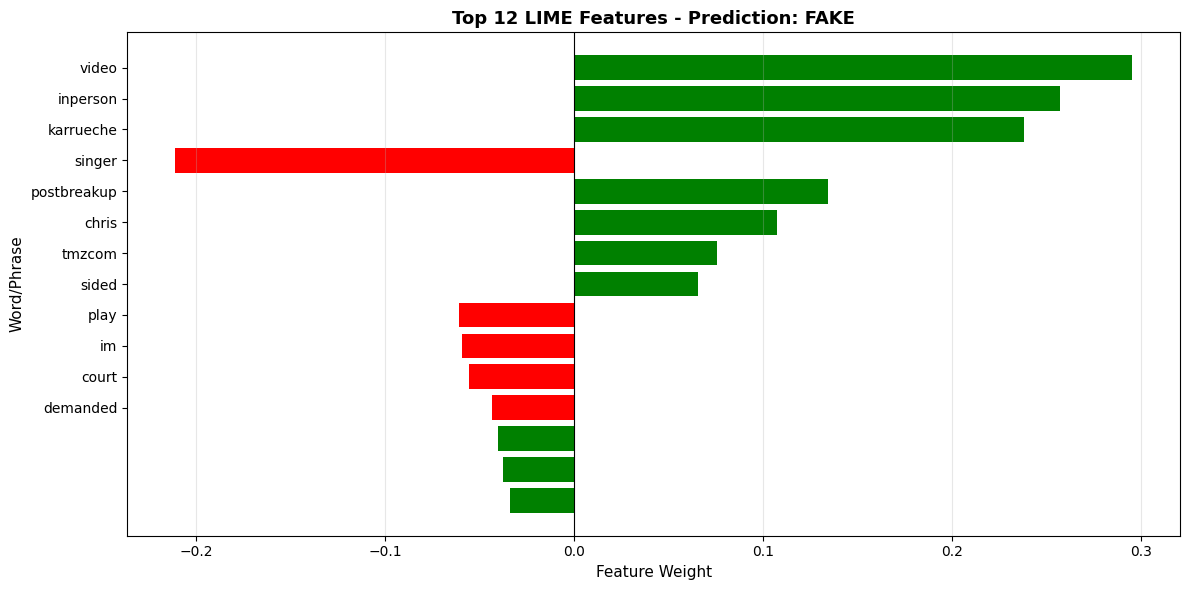


📄 Article Text (top features highlighted):



Example 3: FAKE News → Predicted: REAL
Confidence: 0.9989 | Correct: False


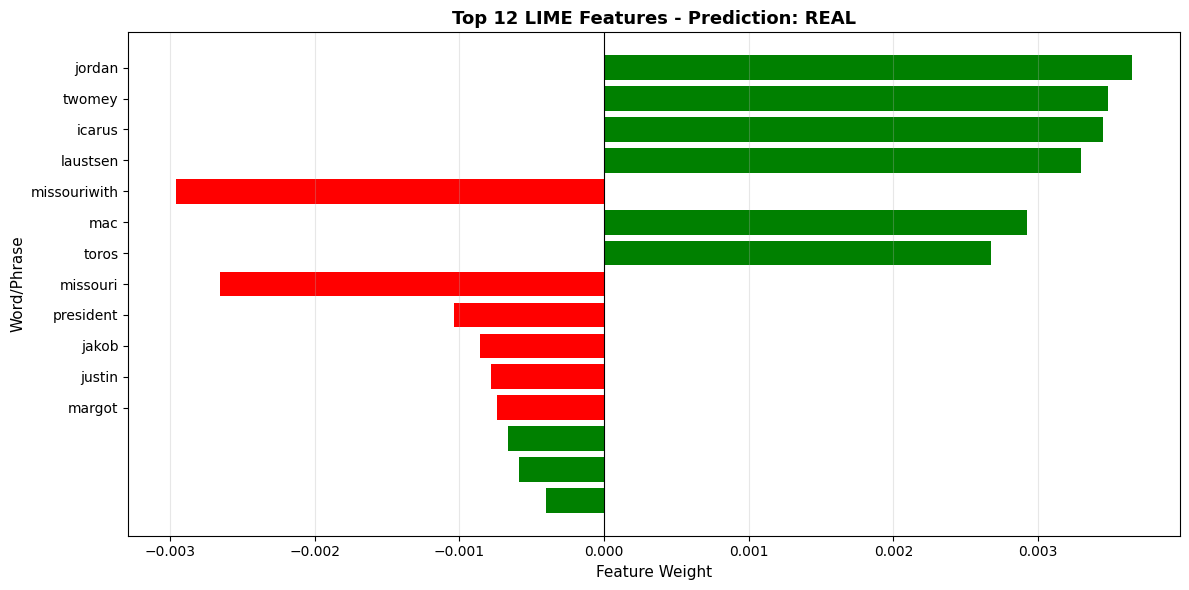


📄 Article Text (top features highlighted):



Example 4: REAL News → Predicted: REAL
Confidence: 0.9994 | Correct: True


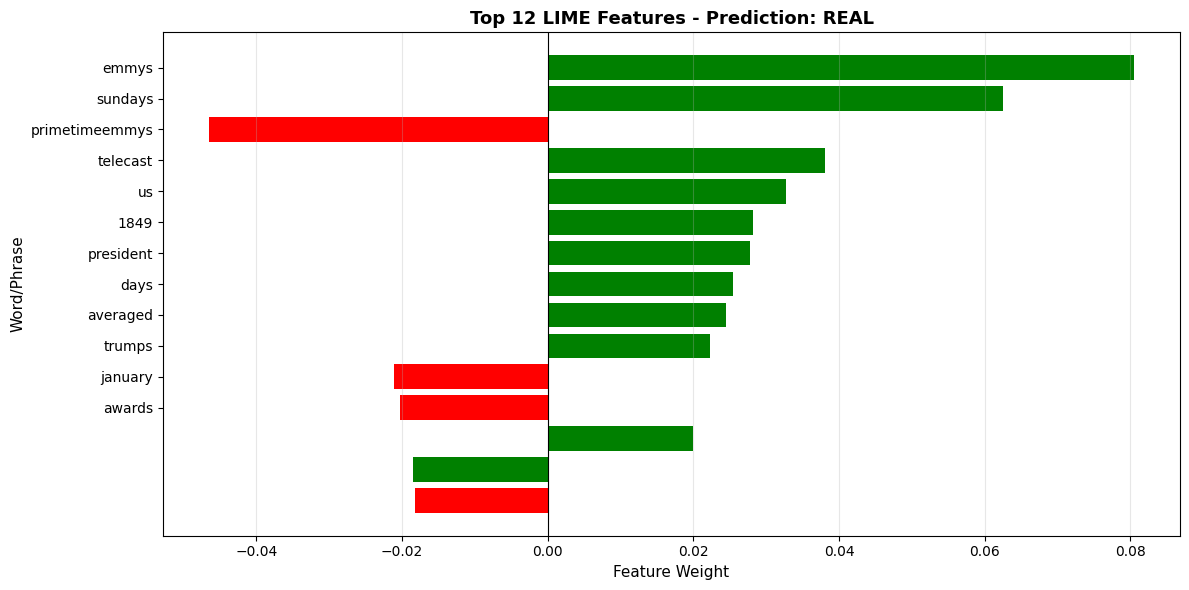


📄 Article Text (top features highlighted):



Example 5: REAL News → Predicted: REAL
Confidence: 0.9994 | Correct: True


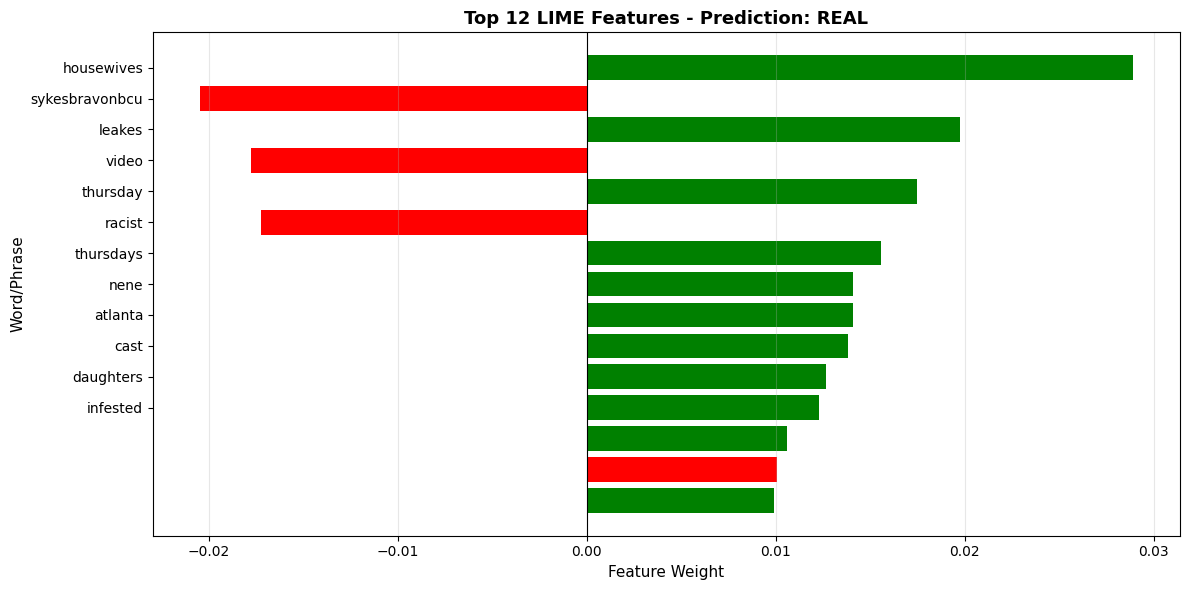


📄 Article Text (top features highlighted):



Example 6: REAL News → Predicted: REAL
Confidence: 0.9982 | Correct: True


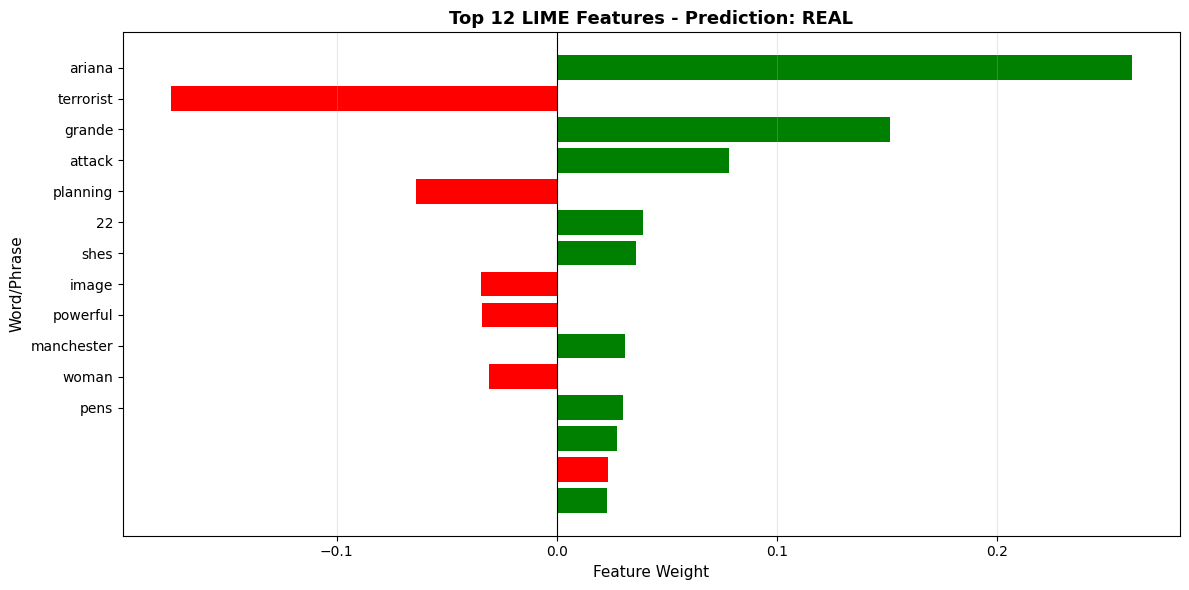


📄 Article Text (top features highlighted):


In [23]:
# Create detailed visualizations for each example (matching TF-IDF style)
from IPython.display import display, HTML

def visualize_lime_explanation(explanation_dict, top_n=15):
    """
    Visualize LIME explanation with bar chart and highlighted text.
    """
    top_features = explanation_dict['top_features']
    prediction = explanation_dict['prediction']
    text = explanation_dict['text']
    probs = explanation_dict['probs']
    
    # Create dataframe from features
    features_list = []
    for word, weight in top_features:
        clean_word = word.replace('<b>', '').replace('</b>', '')
        direction = 'REAL' if weight > 0 else 'FAKE'
        features_list.append({
            'word': clean_word,
            'weight': weight,
            'direction': direction,
            'abs_weight': abs(weight)
        })
    
    df_feat = pd.DataFrame(features_list).sort_values('abs_weight', ascending=False)
    
    # Visualization 1: Bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = df_feat['direction'].map({'REAL': 'green', 'FAKE': 'red'})
    ax.barh(range(len(df_feat)), df_feat['weight'], color=colors.head(top_n))
    ax.set_yticks(range(len(df_feat.head(top_n))))
    ax.set_yticklabels(df_feat['word'].head(top_n))
    ax.set_xlabel('Feature Weight', fontsize=11)
    ax.set_ylabel('Word/Phrase', fontsize=11)
    ax.set_title(f'Top {top_n} LIME Features - Prediction: {prediction}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Visualization 2: Highlighted text
    highlighted_words = []
    text_lower = text.lower()
    for word in df_feat['word'].head(10):
        if word.lower() in text_lower:
            highlighted_words.append(word.lower())
    
    highlighted_html = text
    for word in highlighted_words:
        if word.lower() in df_feat[df_feat['direction'] == 'REAL']['word'].values:
            color = "rgba(0, 200, 0, 0.3)"
        else:
            color = "rgba(255, 0, 0, 0.3)"
        highlighted_html = highlighted_html.replace(word, f"<span style='background-color:{color}'>{word}</span>")
        highlighted_html = highlighted_html.replace(word.capitalize(), f"<span style='background-color:{color}'>{word.capitalize()}</span>")
    
    print(f"\n📄 Article Text (top features highlighted):")
    display(HTML(f"<div style='border:1px solid #ccc; padding:15px; border-radius:5px; background:#f9f9f9'>{highlighted_html[:500]}...</div>"))
    
    return df_feat

print("Detailed visualizations for each example:\n")
print("="*70)

for i, exp in enumerate(all_explanations):
    print(f"\nExample {i+1}: {exp['true_label']} News → Predicted: {exp['prediction']}")
    print(f"Confidence: {exp['confidence']:.4f} | Correct: {exp['correct']}")
    df_feat = visualize_lime_explanation(exp, top_n=12)

## Performance Summary

In [25]:
# Summary statistics and comparison table
correct_predictions = sum(1 for exp in all_explanations if exp['correct'])
accuracy = correct_predictions / len(all_explanations)

print("\n" + "="*70)
print("BERT INTERPRETABILITY ANALYSIS SUMMARY")
print("="*70)

print(f"\n📊 Sample Performance:")
print(f"  Accuracy: {accuracy:.2%} ({correct_predictions}/{len(all_explanations)} correct)")

# Create comparison table
comparison_results = []
for i, exp in enumerate(all_explanations, 1):
    top_positive = ', '.join([w.replace('<b>', '').replace('</b>', '') for w, wt in exp['top_features'] if wt > 0][:3])
    top_negative = ', '.join([w.replace('<b>', '').replace('</b>', '') for w, wt in exp['top_features'] if wt < 0][:3])
    
    comparison_results.append({
        'Example': i,
        'True Label': exp['true_label'],
        'Prediction': exp['prediction'],
        'Correct': '✅' if exp['correct'] else '❌',
        'Confidence': f"{exp['confidence']:.4f}",
        'Top Supporting': top_positive if exp['prediction'] == 'REAL' else top_negative,
        'Top Against': top_negative if exp['prediction'] == 'REAL' else top_positive
    })

df_comparison = pd.DataFrame(comparison_results)
print("\n📋 Detailed Results Table:")
display(df_comparison)


print(f"\n" + "="*70)


BERT INTERPRETABILITY ANALYSIS SUMMARY

📊 Sample Performance:
  Accuracy: 83.33% (5/6 correct)

📋 Detailed Results Table:


,Example,True Label,Prediction,Correct,Confidence,Top Supporting,Top Against
0,1,FAKE,FAKE,✅,0.9938,"thank, fearless, 20","degeneres, rumors, ellen"
1,2,FAKE,FAKE,✅,1.0000,"singer, play, im","video, inperson, karrueche"
2,3,FAKE,REAL,❌,0.9989,"jordan, twomey, icarus","missouriwith, missouri, president"
3,4,REAL,REAL,✅,0.9994,"emmys, sundays, telecast","primetimeemmys, january, awards"
4,5,REAL,REAL,✅,0.9994,"housewives, leakes, thursday","sykesbravonbcu, video, racist"
5,6,REAL,REAL,✅,0.9982,"ariana, grande, attack","terrorist, planning, image"
